<a href="https://colab.research.google.com/github/Clean2105/Clean2105/blob/main/MAYHOCAIPHONGCHONGGIANLANTHICUBANGCACHNANGDIEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- ĐANG KHỞI TẠO BIỂU ĐỒ TRỰC QUAN HÓA HÀNH VI ---


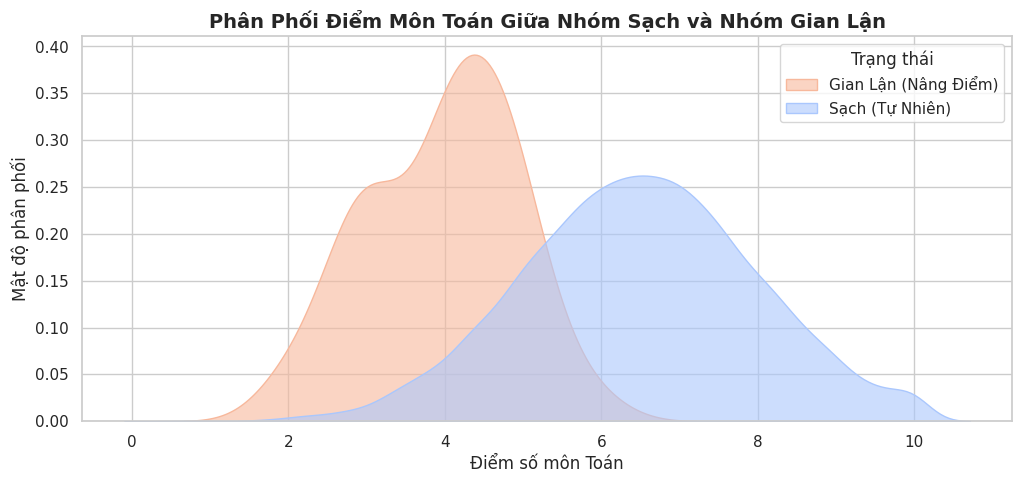

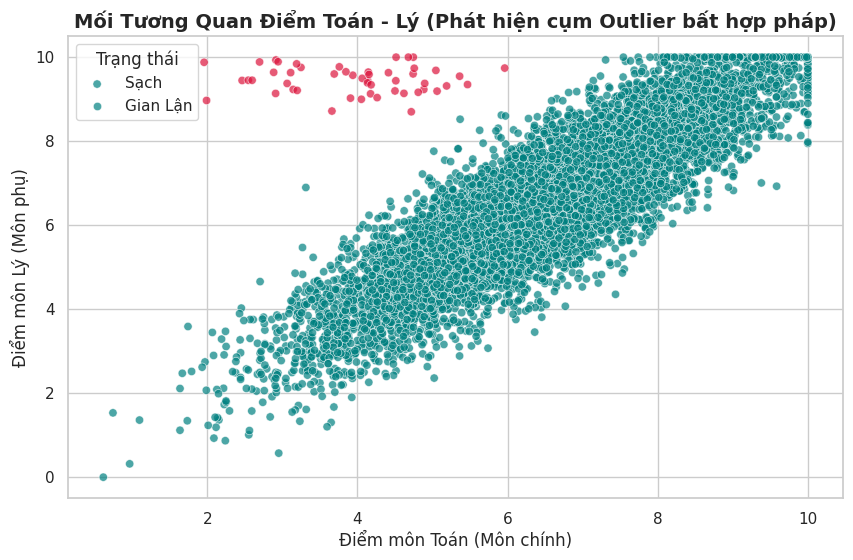

/tmp/ipykernel_859/1473308403.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Label', y='Ti_Le_Phu_Chinh', palette='Set2')


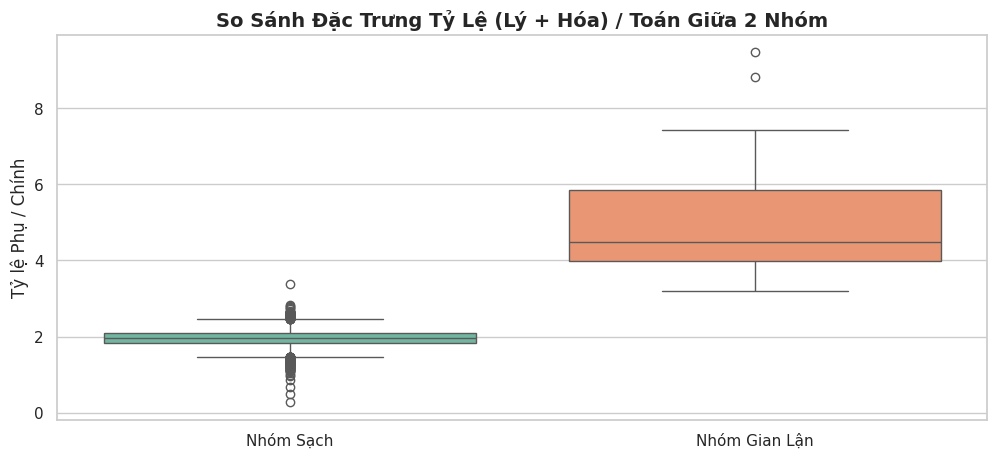


--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST K-FOLD ---
              precision    recall  f1-score   support

        Sach       1.00      1.00      1.00      1990
    Gian Lan       1.00      1.00      1.00        10

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 1.0000


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb

# Thiết lập giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

# ==========================================
# 1. GIẢ LẬP DỮ LIỆU ĐIỂM THI (DATA SIMULATION)
# ==========================================
np.random.seed(42)
n_samples = 10000

toan_sach = np.clip(np.random.normal(6.5, 1.5, n_samples), 0, 10)
ly_sach = np.clip(toan_sach + np.random.normal(0, 0.8, n_samples), 0, 10)
hoa_sach = np.clip(toan_sach + np.random.normal(0, 0.9, n_samples), 0, 10)

df = pd.DataFrame({'Toan': toan_sach, 'Ly': ly_sach, 'Warm_up': hoa_sach})
df.rename(columns={'Warm_up': 'Hoa'}, inplace=True)
df['Label'] = 0  # 0: Sạch

n_fraud = int(n_samples * 0.005)
fraud_indices = np.random.choice(n_samples, n_fraud, replace=False)

df.loc[fraud_indices, 'Toan'] = np.clip(np.random.normal(4.0, 1.0, n_fraud), 0, 10)
df.loc[fraud_indices, 'Ly'] = np.clip(np.random.normal(9.5, 0.3, n_fraud), 8, 10)
df.loc[fraud_indices, 'Hoa'] = np.clip(np.random.normal(9.6, 0.2, n_fraud), 8, 10)
df.loc[fraud_indices, 'Label'] = 1  # 1: Gian lận nâng điểm

# ==========================================
# 2. KỸ NGHỆ ĐẶC TRƯNG (FEATURE ENGINEERING)
# ==========================================
df['Khoang_Cach_Diem'] = df[['Toan', 'Ly', 'Hoa']].std(axis=1)
df['Ti_Le_Phu_Chinh'] = (df['Ly'] + df['Hoa']) / (df['Toan'] + 0.1)

# ==========================================
# 🆕 BỔ SUNG: TRỰC QUAN HÓA DỮ LIỆU (EDA WITH MATPLOTLIB & SEABORN)
# ==========================================
print("--- ĐANG KHỞI TẠO BIỂU ĐỒ TRỰC QUAN HÓA HÀNH VI ---")

# Biểu đồ 1: Phân phối Mật độ điểm môn Toán (Tìm điểm trũng / phình bất thường)
plt.figure(figsize=(12, 5))
sns.kdeplot(data=df, x='Toan', hue='Label', fill=True, common_norm=False, palette='coolwarm', alpha=0.6)
plt.title('Phân Phối Điểm Môn Toán Giữa Nhóm Sạch và Nhóm Gian Lận', fontsize=14, fontweight='bold')
plt.xlabel('Điểm số môn Toán')
plt.ylabel('Mật độ phân phối')
plt.legend(title='Trạng thái', labels=['Gian Lận (Nâng Điểm)', 'Sạch (Tự Nhiên)'])
plt.show()

# Biểu đồ 2: Scatter Plot thể hiện sự bất thường giữa môn Toán và môn Lý
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Toan', y='Ly', hue='Label', palette={0: 'teal', 1: 'crimson'}, alpha=0.7, edgecolor='w')
plt.title('Mối Tương Quan Điểm Toán - Lý (Phát hiện cụm Outlier bất hợp pháp)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm môn Toán (Môn chính)')
plt.ylabel('Điểm môn Lý (Môn phụ)')
plt.legend(title='Trạng thái', labels=['Sạch', 'Gian Lận'])
plt.show()

# Biểu đồ 3: Phân phối của Đặc trưng "Ti_Le_Phu_Chinh" - Vũ khí phân loại chính của AI
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Label', y='Ti_Le_Phu_Chinh', palette='Set2')
plt.title('So Sánh Đặc Trưng Tỷ Lệ (Lý + Hóa) / Toán Giữa 2 Nhóm', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Nhóm Sạch', 'Nhóm Gian Lận'])
plt.xlabel('')
plt.ylabel('Tỷ lệ Phụ / Chính')
plt.show()

# ==========================================
# 3. TẦNG 1: SÀNG LỌC OUTLIER (ISOLATION FOREST)
# ==========================================
features = ['Toan', 'Ly', 'Hoa', 'Khoang_Cach_Diem', 'Ti_Le_Phu_Chinh']
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df['Anomaly_Score'] = iso_forest.fit_predict(df[features])
df['Anomaly_Score'] = np.where(df['Anomaly_Score'] == -1, 1, 0)

# ==========================================
# 4. TẦNG 2: HUẤN LUYỆN MÔ HÌNH LIGHTGBM
# ==========================================
X = df[features + ['Anomaly_Score']]
y = df['Label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    scale_weight = (len(y_train) - sum(y_train)) / sum(y_train)

    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]

    print("\n--- ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST K-FOLD ---")
    print(classification_report(y_test, preds, target_names=['Sach', 'Gian Lan']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, pred_proba):.4f}")
    break